In [1]:
import pandas as pd
import numpy as np
import os

# Check current working directory (optional)
print("Current working directory:", os.getcwd())

# Read the CSV file
df = pd.read_csv(r'/root/autodl-tmp/clean AAC concrete dataset large ratio.csv')

# Remove the row where the "Ref." column equals "[107]"
df = df[~df["Ref."].isin(["[107]"])]

# Define original feature columns and target columns
original_feature_cols = [
    "SiO2", "Al2O3", "Fe2O3", "CaO", "MgO", "Na2O", "K2O", "SO3",
    "TiO2", "P2O5", "SrO", "Mn2O3", "MnO", "LOI", 
    "AL/B", "SH/SS", "Ms", "Ag/B", "W/B", "Sp/B",
    "Initial curing time (day)", "Initial curing temp (C)", 
    "Initial curing rest time (day)", "Final curing temp (C)", 
    "Concentration (M) NaOH"
]

target_cols = ["7d CS", "28d CS"]

# Drop unwanted columns: "MnO", "Initial curing time (day)", "Initial curing rest time (day)"
cols_to_drop = ["MnO", "Initial curing time (day)", "Initial curing rest time (day)"]
df = df.drop(columns=cols_to_drop)

# Update the feature columns list accordingly (remove dropped columns)
feature_cols = [
    "SiO2", "Al2O3", "Fe2O3", "CaO", "MgO", "Na2O", "K2O", "SO3",
    "TiO2", "P2O5", "SrO", "Mn2O3", "LOI", 
    "AL/B", "SH/SS", "Ms", "Ag/B", "W/B", "Sp/B",
    "Initial curing temp (C)", "Final curing temp (C)", 
    "Concentration (M) NaOH"
]

# Convert target columns to numeric (replacing empty strings with NaN)
for col in target_cols:
    df[col] = pd.to_numeric(df[col].replace(' ', np.nan), errors='coerce')

# Print missing values in target columns
print("Missing values in target columns:")
print(df[target_cols].isnull().sum())

# Drop rows with missing target values
df_clean = df.dropna(subset=target_cols)
print(f"Dataset shape after dropping rows with missing targets: {df_clean.shape}")

# Fill missing values in specific feature columns using the median
df_clean["Na2O"] = df_clean["Na2O"].fillna(df_clean["Na2O"].median())
df_clean["Concentration (M) NaOH"] = df_clean["Concentration (M) NaOH"].fillna(df_clean["Concentration (M) NaOH"].median())

# Extract feature and target arrays
X = df_clean[feature_cols].values
y_7 = df_clean["7d CS"].values
y_28 = df_clean["28d CS"].values

print("X shape:", X.shape)
print("y_7 shape:", y_7.shape)
print("y_28 shape:", y_28.shape)


Current working directory: /root/autodl-tmp
Missing values in target columns:
7d CS     621
28d CS    667
dtype: int64
Dataset shape after dropping rows with missing targets: (603, 73)
X shape: (603, 22)
y_7 shape: (603,)
y_28 shape: (603,)


/tmp/ipykernel_2219/2689578683.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Na2O"] = df_clean["Na2O"].fillna(df_clean["Na2O"].median())
/tmp/ipykernel_2219/2689578683.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Concentration (M) NaOH"] = df_clean["Concentration (M) NaOH"].fillna(df_clean["Concentration (M) NaOH"].median())


In [2]:
stats = df_clean[["7d CS", "28d CS"]].describe()
print(stats)


            7d CS      28d CS
count  603.000000  603.000000
mean    32.356671   38.768486
std     13.560113   14.254611
min      2.900000    6.055100
25%     22.497550   28.892000
50%     31.616000   36.800000
75%     42.321150   49.823780
max     67.600000   77.357500


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: Display summary statistics to check scaling
import pandas as pd
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("Summary statistics for scaled features:")
print(scaled_df.describe().loc[['mean', 'std']].T)

Summary statistics for scaled features:
                                 mean      std
SiO2                    -3.004783e-16  1.00083
Al2O3                   -2.356692e-17  1.00083
Fe2O3                    0.000000e+00  1.00083
CaO                      1.178346e-16  1.00083
MgO                     -1.060512e-16  1.00083
Na2O                     1.178346e-17  1.00083
K2O                     -2.121023e-16  1.00083
SO3                     -1.060512e-16  1.00083
TiO2                    -4.713385e-17  1.00083
P2O5                    -1.178346e-16  1.00083
SrO                      0.000000e+00  1.00083
Mn2O3                    2.356692e-17  1.00083
LOI                      3.535038e-17  1.00083
AL/B                     3.004783e-16  1.00083
SH/SS                   -4.713385e-17  1.00083
Ms                       4.713385e-16  1.00083
Ag/B                     2.651279e-16  1.00083
W/B                      1.001594e-16  1.00083
Sp/B                    -5.891731e-17  1.00083
Initial curing temp 

In [4]:
# Check missing values in the original DataFrame for feature and target columns
print("Missing values in original DataFrame:")
print(df[feature_cols + target_cols].isnull().sum())

# Check missing values in cleaned DataFrame
print("Missing values in cleaned DataFrame:")
print(df_clean[feature_cols + target_cols].isnull().sum())


Missing values in original DataFrame:
SiO2                         0
Al2O3                        0
Fe2O3                        0
CaO                          0
MgO                          0
Na2O                         1
K2O                          2
SO3                          0
TiO2                         0
P2O5                         0
SrO                          0
Mn2O3                        0
LOI                          0
AL/B                         0
SH/SS                        0
Ms                           0
Ag/B                         0
W/B                          0
Sp/B                         0
Initial curing temp (C)      1
Final curing temp (C)        0
Concentration (M) NaOH      18
7d CS                      621
28d CS                     667
dtype: int64
Missing values in cleaned DataFrame:
SiO2                       0
Al2O3                      0
Fe2O3                      0
CaO                        0
MgO                        0
Na2O                   

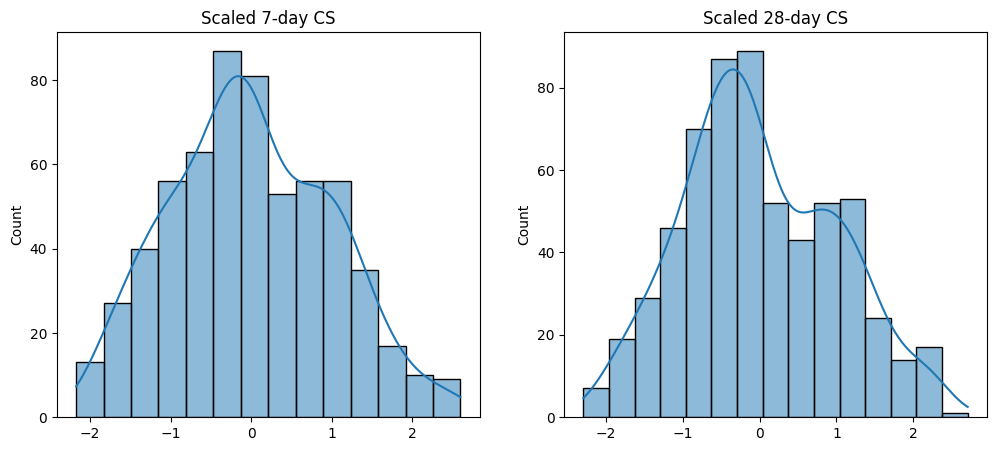

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for targets (assumes y_7 and y_28 are defined from your cleaned dataset)
targets_df = pd.DataFrame({
    "7d CS": y_7,
    "28d CS": y_28
})

# Initialize and fit a scaler on the targets
target_scaler = StandardScaler()
targets_scaled = target_scaler.fit_transform(targets_df)

# Split the scaled targets into separate arrays
y_7_scaled = targets_scaled[:, 0]
y_28_scaled = targets_scaled[:, 1]

# Optional: Visualize the scaled target distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y_7_scaled, kde=True)
plt.title("Scaled 7-day CS")

plt.subplot(1, 2, 2)
sns.histplot(y_28_scaled, kde=True)
plt.title("Scaled 28-day CS")
plt.show()

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ConcreteDatasetScaled(Dataset):
    def __init__(self, features, y_7_scaled, y_28_scaled):
        # features is already scaled (X_scaled)
        self.z = torch.tensor(features, dtype=torch.float32)
        # Combine scaled targets into a tensor of shape (n_samples, 2)
        self.y = torch.tensor(np.vstack((y_7_scaled, y_28_scaled)).T, dtype=torch.float32)
        # Fixed time vector for all samples
        self.t = torch.tensor([7.0, 28.0], dtype=torch.float32)
    
    def __len__(self):
        return self.z.shape[0]
    
    def __getitem__(self, idx):
        return self.z[idx], self.t, self.y[idx]

# Create the dataset and DataLoader (using full-batch training)
dataset_scaled = ConcreteDatasetScaled(X_scaled, y_7_scaled, y_28_scaled)
dataloader_scaled = DataLoader(dataset_scaled, batch_size=len(dataset_scaled))  # full batch

print("Dataset size (scaled targets):", len(dataset_scaled))


Dataset size (scaled targets): 603


In [6]:
# (1) Converted "7d CS" and "28d CS" to numeric and dropped rows with missing targets:
for col in target_cols:
    df[col] = pd.to_numeric(df[col].replace(' ', np.nan), errors='coerce')
df_clean = df.dropna(subset=target_cols)

# (2) Filled any remaining feature‐column NaNs (e.g. for "Na2O" and "Concentration (M) NaOH") as you showed.

# Now, simply do:
print("\nDescriptive statistics for targets:")
print(df_clean[target_cols].describe())



Descriptive statistics for targets:
            7d CS      28d CS
count  603.000000  603.000000
mean    32.356671   38.768486
std     13.560113   14.254611
min      2.900000    6.055100
25%     22.497550   28.892000
50%     31.616000   36.800000
75%     42.321150   49.823780
max     67.600000   77.357500


In [7]:
import matplotlib.pyplot as plt

# 1) Ask for a generic “serif” family.
plt.rcParams['font.family'] = 'serif'

# 2) Tell it which serif names to try, in order.
#    • If Times New Roman is not found, it will pick Liberation Serif, then DejaVu Serif.
plt.rcParams['font.serif'] = [
    'Times New Roman',    # preferred, but probably missing
    'Liberation Serif',   # almost identical-looking fallback
    'DejaVu Serif'        # second fallback
]

# 3) Turn OFF any grids:
plt.rcParams['axes.grid'] = False

# 4) Set a default font size you like:
plt.rcParams['font.size'] = 10


In [8]:
import matplotlib.font_manager as fm

# Get a sorted list of unique font names on disk
all_fonts = fm.findSystemFonts(fontpaths=None, fontext='ttf')
names = sorted({
    fm.FontProperties(fname=fp).get_name()
    for fp in all_fonts
})
print(names)


['DejaVu Sans', 'DejaVu Sans Mono', 'DejaVu Serif']


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Use a plain white Seaborn style (no grid by default):
sns.set_style("white")

# 2) Force Matplotlib to use a serif font, specifically DejaVu Serif:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['DejaVu Serif']
plt.rcParams['font.size']   = 10

# 3) Ensure any grid is turned off:
plt.rcParams['axes.grid']   = False

# (Optional) If you like Seaborn colour palettes:
sns.set_palette("husl")


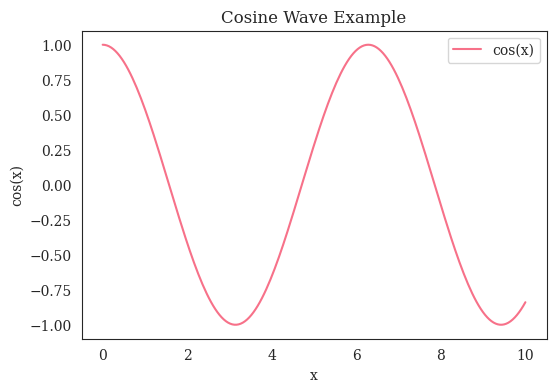

In [10]:
import numpy as np

x = np.linspace(0, 10, 200)
y = np.cos(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label="cos(x)")
plt.title("Cosine Wave Example")
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.legend()
plt.show()



CORRELATION ANALYSIS

Top 10 features correlated with 7d CS:
  Fe₂O₃: 0.299
  CaO: 0.295
  Initial Curing Temp (°C): 0.237
  Na₂O: 0.226
  SiO₂: 0.194
  SO₃: 0.151
  TiO₂: 0.147
  LOI: 0.136
  Al₂O₃: 0.129
  Final Curing Temp (°C): 0.128

Top 10 features correlated with 28d CS:
  CaO: 0.363
  Fe₂O₃: 0.326
  SiO₂: 0.303
  SO₃: 0.233
  Final Curing Temp (°C): 0.205
  Al₂O₃: 0.189
  Na₂O: 0.181
  MgO: 0.177
  SH/SS: 0.125
  NaOH Concentration (M): 0.118

Correlation heatmap saved as 'correlation.png'


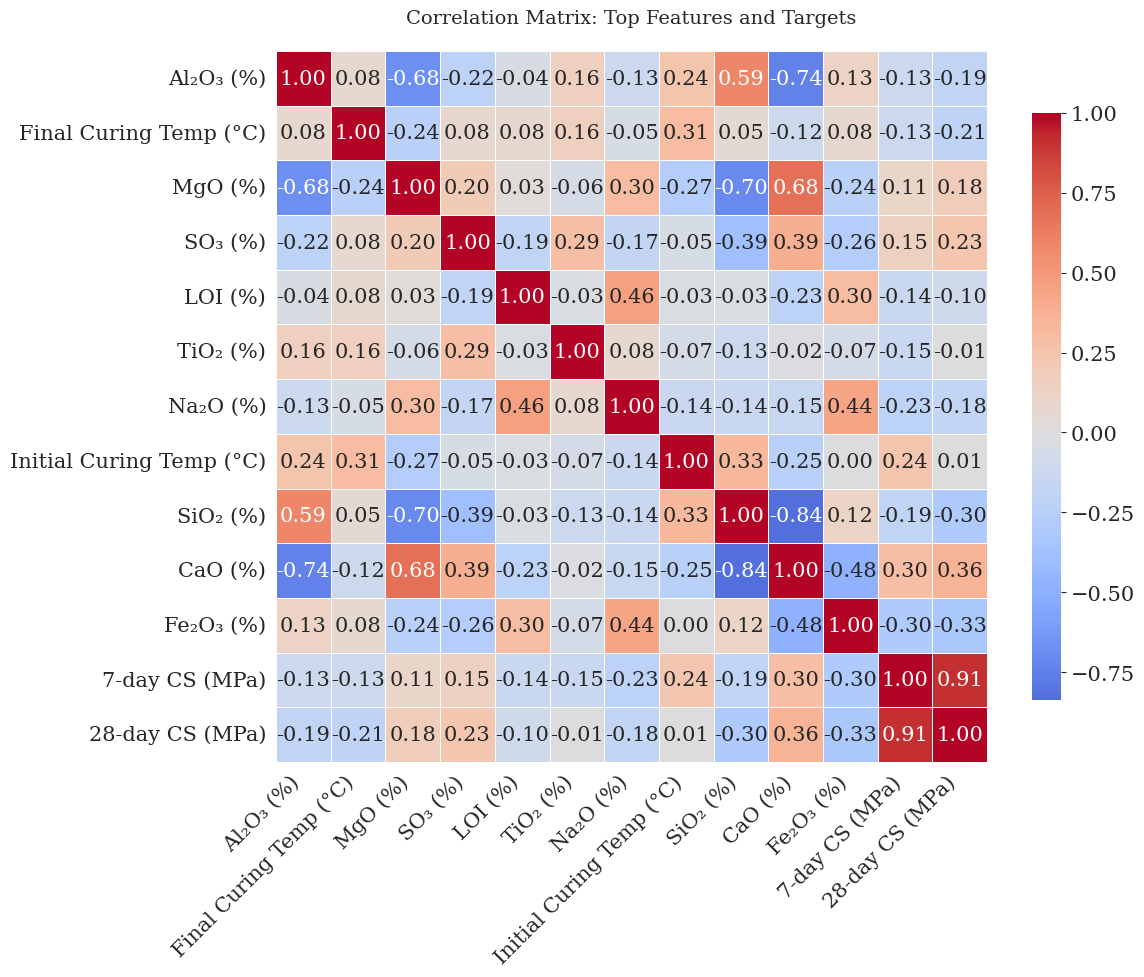

In [23]:
# =============================================================================
# 6. Correlation Analysis with Units
# =============================================================================
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Calculate correlation matrix
correlation_matrix = df_clean[feature_cols + target_cols].corr()

# Find top correlations with targets
print("\nTop 10 features correlated with 7d CS:")
corr_7d = correlation_matrix['7d CS'].drop(['7d CS', '28d CS']).abs().sort_values(ascending=False).head(10)
for feat, corr in corr_7d.items():
    display_name = oxide_labels.get(feat, mix_labels.get(feat, feat))
    print(f"  {display_name}: {corr:.3f}")

print("\nTop 10 features correlated with 28d CS:")
corr_28d = correlation_matrix['28d CS'].drop(['7d CS', '28d CS']).abs().sort_values(ascending=False).head(10)
for feat, corr in corr_28d.items():
    display_name = oxide_labels.get(feat, mix_labels.get(feat, feat))
    print(f"  {display_name}: {corr:.3f}")

# Correlation heatmap for top features
top_features = list(set(corr_7d.head(8).index.tolist() + corr_28d.head(8).index.tolist()))
selected_cols = top_features + target_cols

# Create labels for heatmap with proper units
heatmap_labels_with_units = []
for col in selected_cols:
    if col in oxide_labels:
        # Add % for oxides
        heatmap_labels_with_units.append(oxide_labels[col] + ' (%)')
    elif col == "Initial curing temp (C)":
        heatmap_labels_with_units.append("Initial Curing Temp (°C)")
    elif col == "Final curing temp (C)":
        heatmap_labels_with_units.append("Final Curing Temp (°C)")
    elif col == "Concentration (M) NaOH":
        heatmap_labels_with_units.append("NaOH Concentration (M)")
    elif col in mix_labels:
        # Mix design parameters don't have units
        heatmap_labels_with_units.append(mix_labels[col])
    elif col == "7d CS":
        heatmap_labels_with_units.append("7-day CS (MPa)")
    elif col == "28d CS":
        heatmap_labels_with_units.append("28-day CS (MPa)")
    else:
        heatmap_labels_with_units.append(col)

# Create the correlation heatmap
fig_corr = plt.figure(figsize=(12, 10))
ax = sns.heatmap(df_clean[selected_cols].corr(), 
                 annot=True, 
                 fmt='.2f', 
                 cmap='coolwarm', 
                 center=0, 
                 square=True, 
                 linewidths=0.5,
                 xticklabels=heatmap_labels_with_units, 
                 yticklabels=heatmap_labels_with_units,
                 cbar_kws={"shrink": .8})

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Add title
plt.title('Correlation Matrix: Top Features and Targets', fontsize=14, pad=20)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
fig_corr.savefig('correlation.png', dpi=300, bbox_inches='tight')
print("\nCorrelation heatmap saved as 'correlation.png'")

plt.show()

In [15]:
plt.rcParams['axes.grid'] = False

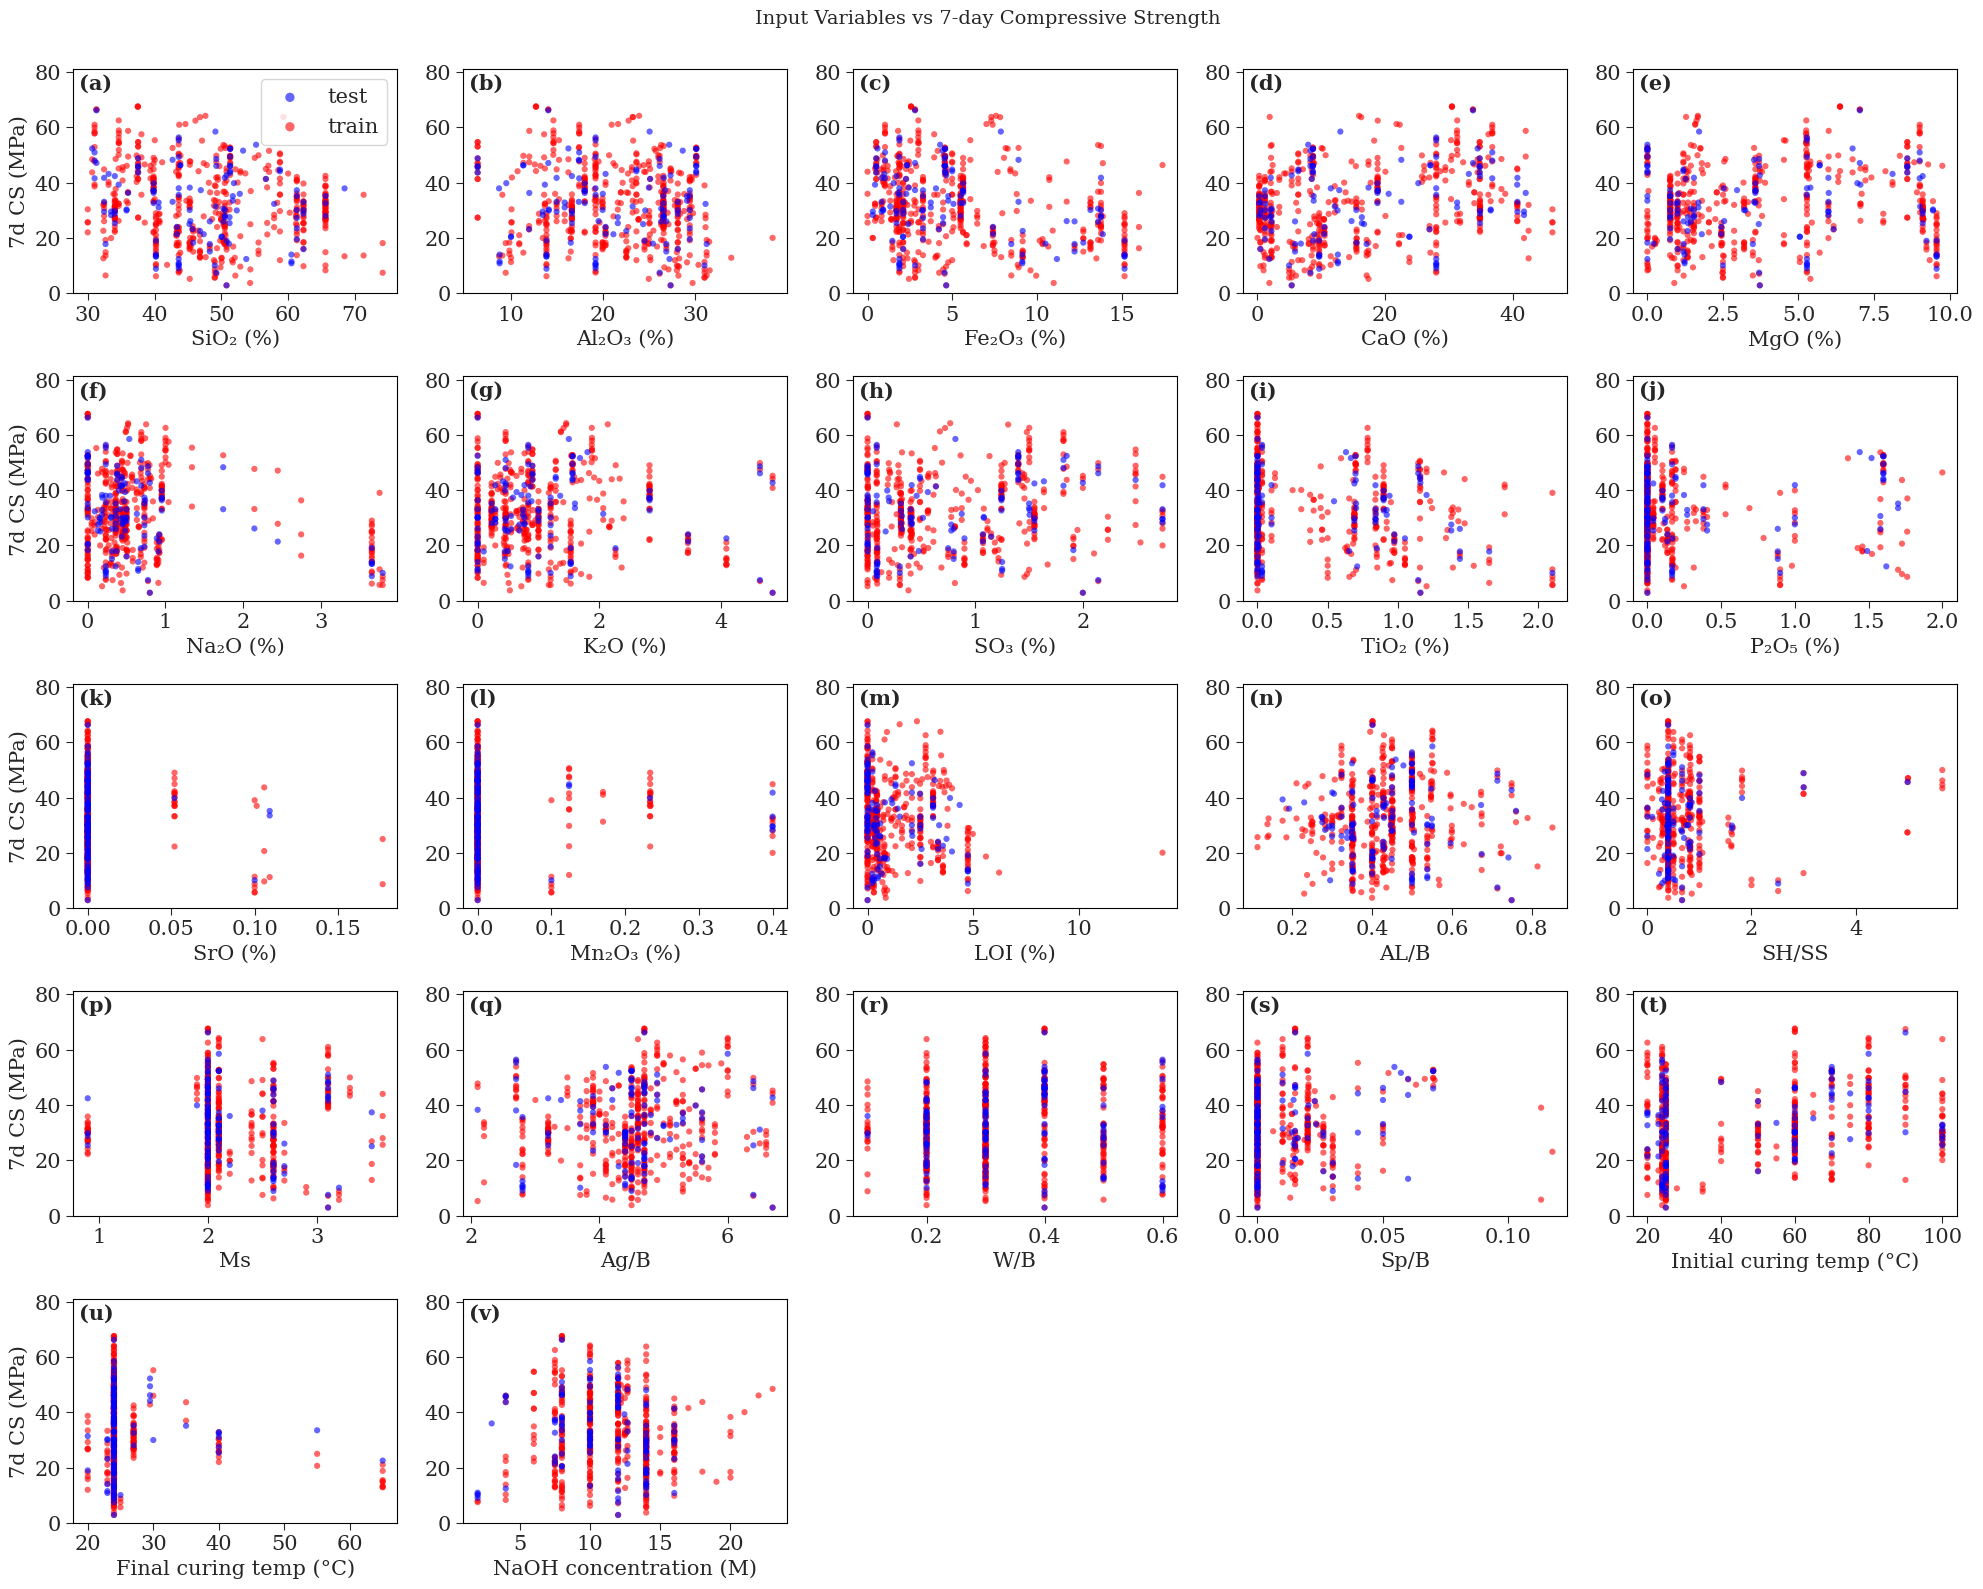

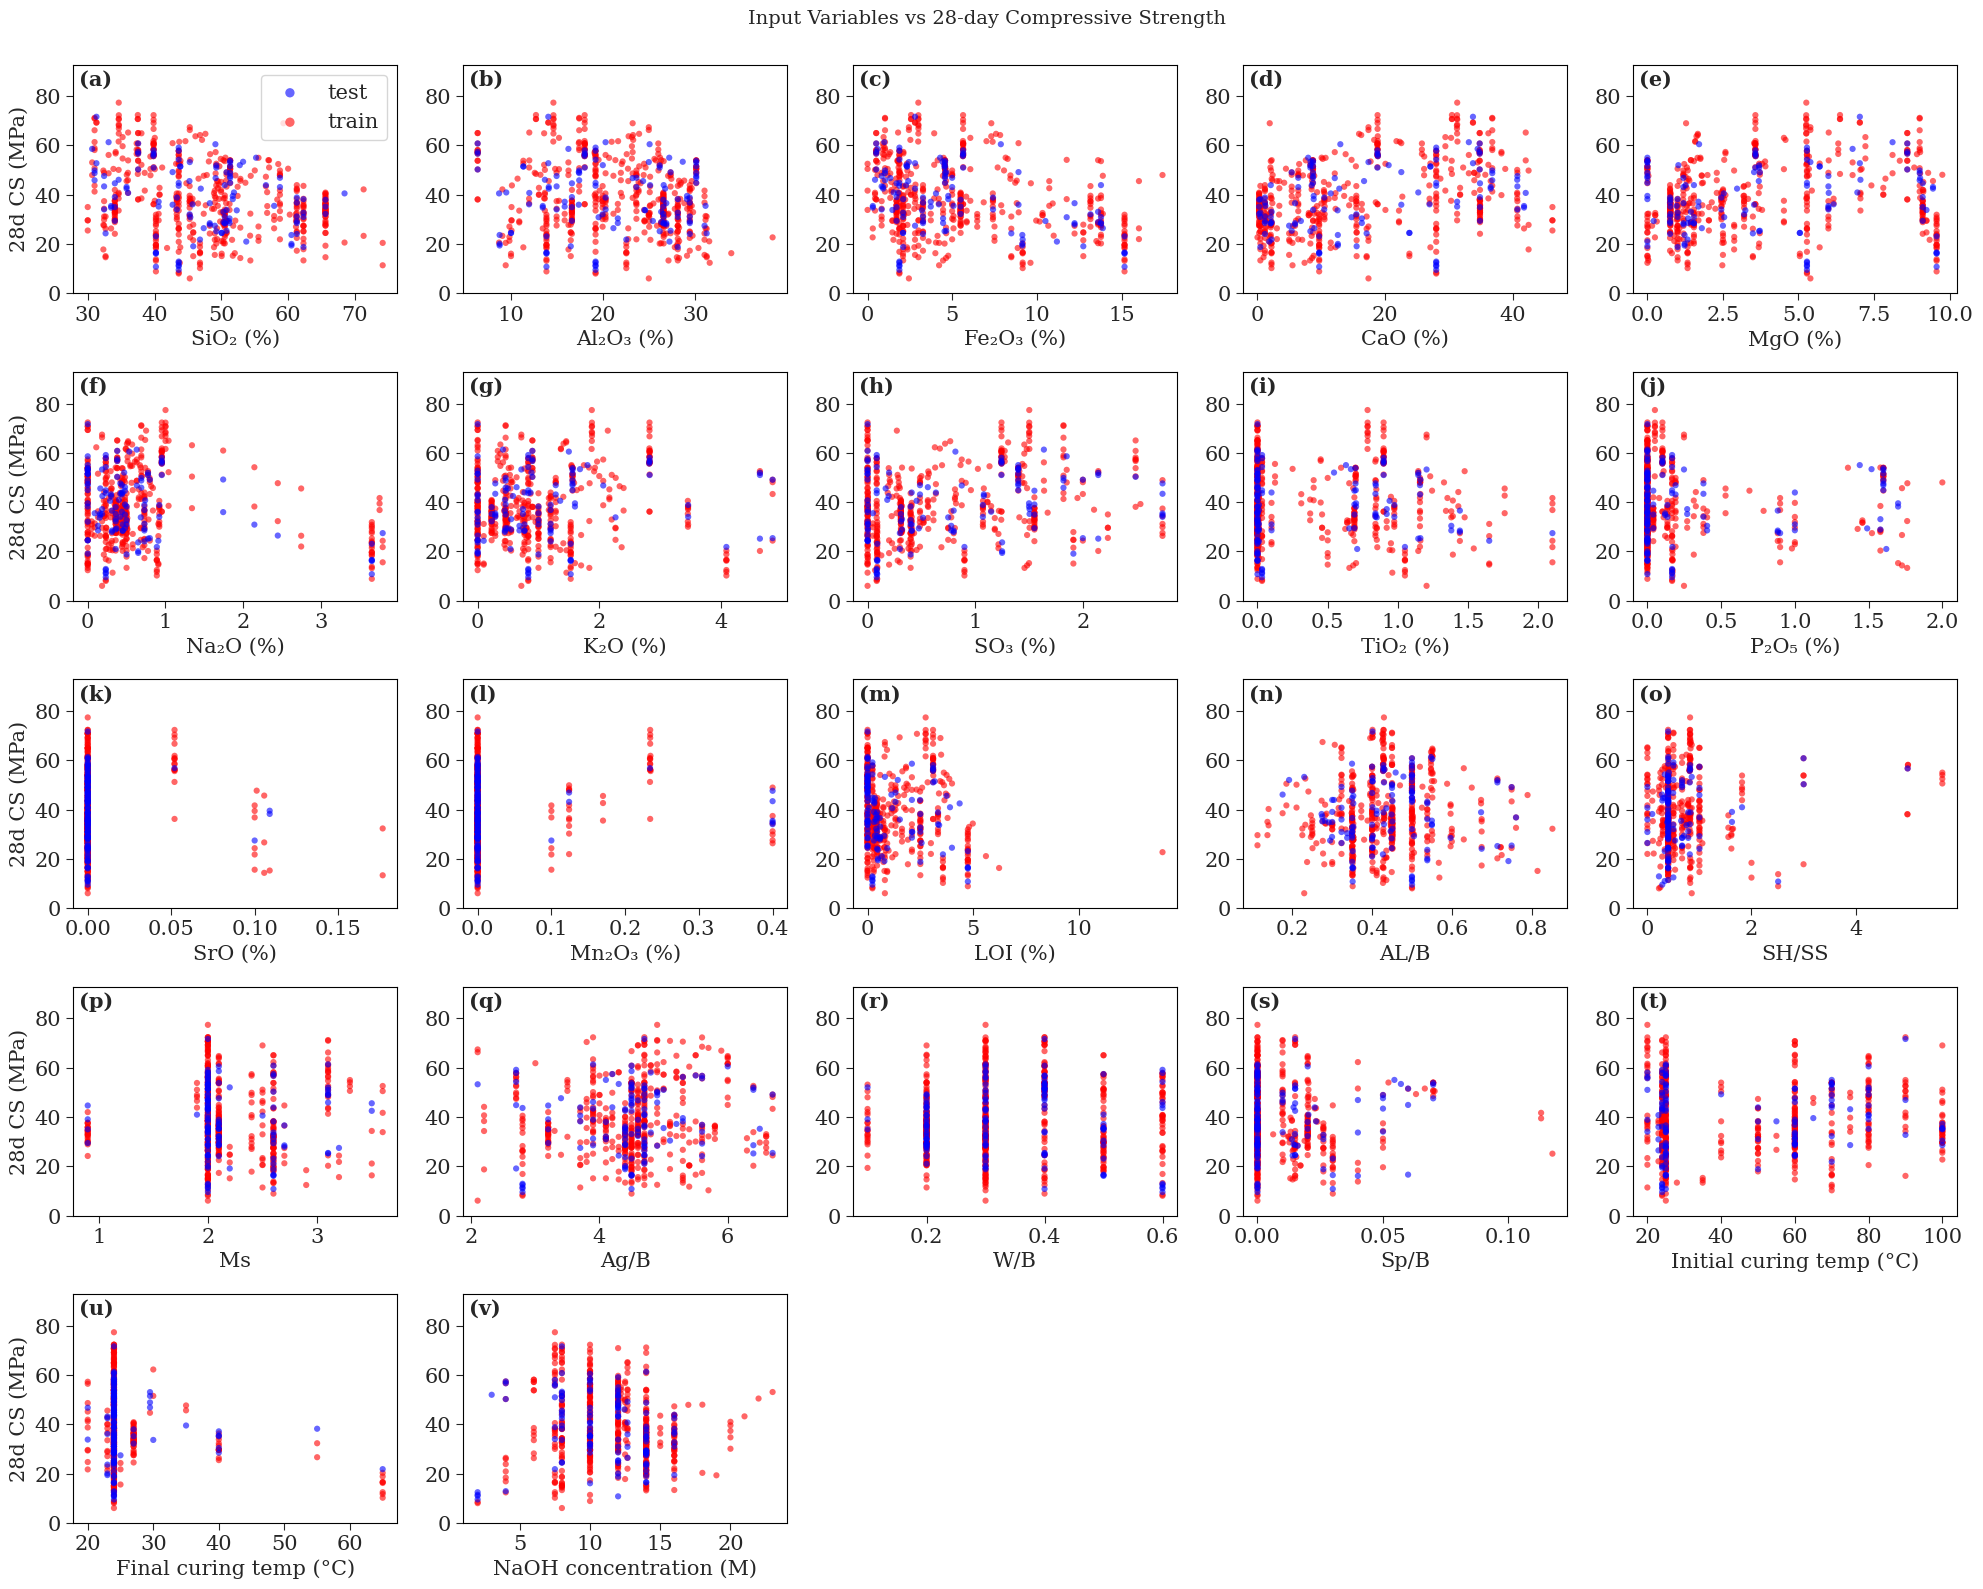


Scatter plot analysis complete!
Total features plotted: 22
Training samples: 482 (red)
Test samples: 121 (blue)

7-day CS range: 2.9 - 67.6 MPa
28-day CS range: 6.1 - 77.4 MPa


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =============================================================================
# PLOTTING STYLE CONFIGURATION
# =============================================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = False  # NO GRID

# Define colors - using your preferred blue/red scheme
COLORS = {
    'train': 'red',      # Red for training
    'test': 'blue',      # Blue for test
    'train_alpha': 0.6,
    'test_alpha': 0.6
}

# All feature columns
feature_cols = [
    "SiO2", "Al2O3", "Fe2O3", "CaO", "MgO", "Na2O", "K2O", "SO3",
    "TiO2", "P2O5", "SrO", "Mn2O3", "LOI", 
    "AL/B", "SH/SS", "Ms", "Ag/B", "W/B", "Sp/B",
    "Initial curing temp (C)", "Final curing temp (C)", 
    "Concentration (M) NaOH"
]

# Label mappings with units
feature_labels = {
    # Oxides (%)
    "SiO2": "SiO₂ (%)", "Al2O3": "Al₂O₃ (%)", "Fe2O3": "Fe₂O₃ (%)",
    "CaO": "CaO (%)", "MgO": "MgO (%)", "Na2O": "Na₂O (%)",
    "K2O": "K₂O (%)", "SO3": "SO₃ (%)", "TiO2": "TiO₂ (%)",
    "P2O5": "P₂O₅ (%)", "SrO": "SrO (%)", "Mn2O3": "Mn₂O₃ (%)",
    "LOI": "LOI (%)",
    # Mix design parameters
    "AL/B": "AL/B", "SH/SS": "SH/SS", "Ms": "Ms",
    "Ag/B": "Ag/B", "W/B": "W/B", "Sp/B": "Sp/B",
    # Curing conditions
    "Initial curing temp (C)": "Initial curing temp (°C)",
    "Final curing temp (C)": "Final curing temp (°C)",
    "Concentration (M) NaOH": "NaOH concentration (M)"
}

# Get original (unscaled) data for plotting
X_train_original = scaler.inverse_transform(X_train_full)
X_test_original = scaler.inverse_transform(X_test_clean)

# Get original target values
y_train_original = target_scaler.inverse_transform(
    np.column_stack([y7_train_full, y28_train_full])
)
y_test_original = target_scaler.inverse_transform(
    np.column_stack([y7_test_clean, y28_test_clean])
)

y7_train_original = y_train_original[:, 0]
y28_train_original = y_train_original[:, 1]
y7_test_original = y_test_original[:, 0]
y28_test_original = y_test_original[:, 1]

# =============================================================================
# PLOT 1: All features vs 7-day CS
# =============================================================================
fig1 = plt.figure(figsize=(20, 16))
fig1.suptitle('Input Variables vs 7-day Compressive Strength', fontsize=14, y=0.995)

# Create subplots in a 5x5 grid (22 features + empty spaces)
n_cols = 5
n_rows = 5

for idx, feature in enumerate(feature_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)
    
    # Get feature index
    feature_idx = feature_cols.index(feature)
    
    # Get data
    x_train = X_train_original[:, feature_idx]
    x_test = X_test_original[:, feature_idx]
    y_train = y7_train_original
    y_test = y7_test_original
    
    # Main scatter plot - NO GRID
    ax.scatter(x_test, y_test, 
              alpha=COLORS['test_alpha'], s=20, c=COLORS['test'], 
              label='test', edgecolors='none', zorder=2)
    ax.scatter(x_train, y_train, 
              alpha=COLORS['train_alpha'], s=20, c=COLORS['train'], 
              label='train', edgecolors='none', zorder=1)
    
    # Set limits with padding
    x_all = np.concatenate([x_train, x_test])
    y_all = np.concatenate([y_train, y_test])
    x_min, x_max = x_all.min(), x_all.max()
    x_range = x_max - x_min
    x_padding = x_range * 0.05
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(0, y_all.max() * 1.20)
    
    # Labels
    ax.set_xlabel(feature_labels[feature], fontsize=15)
    if idx % n_cols == 0:  # Only show y-label on leftmost plots
        ax.set_ylabel('7d CS (MPa)', fontsize=15)
    
    # IMPORTANT: Set tick parameters to show tick marks
    ax.tick_params(axis='both', which='major', 
                   labelsize=15, 
                   length=5,        # Length of tick marks
                   width=0.8,       # Width of tick marks
                   direction='out',  # Ticks point inward
                   bottom=True,        # Show ticks on top
                   left=True)      # Show ticks on right
    
    # Add minor ticks
    ax.tick_params(axis='both', which='minor', 
                   length=3, 
                   width=0.5,
                   direction='out',
                   bottom=False,        # Show ticks on top
                   left=False)
    
    # Enable minor ticks
    ax.minorticks_on()
    
    # Add box around plot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
    
    # Add legend only to first plot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=15, markerscale=1.5)
    
    # Add subplot label
    ax.text(0.02, 0.98, f'({chr(97+idx)})', transform=ax.transAxes,
            fontsize=15, va='top', weight='bold')

# Hide extra subplots
for idx in range(len(feature_cols), n_rows * n_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)
    ax.set_visible(False)

plt.tight_layout()
fig1.savefig('features_vs_7d_CS.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PLOT 2: All features vs 28-day CS
# =============================================================================
fig2 = plt.figure(figsize=(20, 16))
fig2.suptitle('Input Variables vs 28-day Compressive Strength', fontsize=14, y=0.995)

for idx, feature in enumerate(feature_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)
    
    # Get feature index
    feature_idx = feature_cols.index(feature)
    
    # Get data
    x_train = X_train_original[:, feature_idx]
    x_test = X_test_original[:, feature_idx]
    y_train = y28_train_original
    y_test = y28_test_original
    
    # Main scatter plot - NO GRID
    ax.scatter(x_test, y_test, 
              alpha=COLORS['test_alpha'], s=20, c=COLORS['test'], 
              label='test', edgecolors='none', zorder=2)
    ax.scatter(x_train, y_train, 
              alpha=COLORS['train_alpha'], s=20, c=COLORS['train'], 
              label='train', edgecolors='none', zorder=1)
    
    # Set limits with padding
    x_all = np.concatenate([x_train, x_test])
    y_all = np.concatenate([y_train, y_test])
    x_min, x_max = x_all.min(), x_all.max()
    x_range = x_max - x_min
    x_padding = x_range * 0.05
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(0, y_all.max() * 1.20)
    
    # Labels
    ax.set_xlabel(feature_labels[feature], fontsize=15)
    if idx % n_cols == 0:  # Only show y-label on leftmost plots
        ax.set_ylabel('28d CS (MPa)', fontsize=15)
    
    # IMPORTANT: Set tick parameters to show tick marks
    ax.tick_params(axis='both', which='major', 
                   labelsize=15, 
                   length=5,        # Length of tick marks
                   width=0.8,       # Width of tick marks
                   direction='out',  # Ticks point inward
                   bottom=True,        # Show ticks on top
                   left=True)      # Show ticks on right
    
    # Add minor ticks
    ax.tick_params(axis='both', which='minor', 
                   length=3, 
                   width=0.5,
                   direction='out',
                   bottom=False,        # Show ticks on top
                   left=False)
    
    # Enable minor ticks
    ax.minorticks_on()
    
    # Add box around plot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
    
    # Add legend only to first plot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=15, markerscale=1.5)
    
    # Add subplot label
    ax.text(0.02, 0.98, f'({chr(97+idx)})', transform=ax.transAxes,
            fontsize=15, va='top', weight='bold')

# Hide extra subplots
for idx in range(len(feature_cols), n_rows * n_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)
    ax.set_visible(False)

plt.tight_layout()
fig2.savefig('features_vs_28d_CS.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
print("\nScatter plot analysis complete!")
print(f"Total features plotted: {len(feature_cols)}")
print(f"Training samples: {len(X_train_full)} (red)")
print(f"Test samples: {len(X_test_clean)} (blue)")
print(f"\n7-day CS range: {y7_train_original.min():.1f} - {y7_train_original.max():.1f} MPa")
print(f"28-day CS range: {y28_train_original.min():.1f} - {y28_train_original.max():.1f} MPa")

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy
import matplotlib.pyplot as plt

# =============================================================================
# 0. Data Preparation for Final Training and Testing
# =============================================================================
# Assume X_scaled, y_7_scaled, y_28_scaled, and targets_df are available.
# Split: 80% for training and 20% for testing.
X_train_full, X_test, y7_train_full, y7_test, y28_train_full, y28_test = train_test_split(
    X_scaled, y_7_scaled, y_28_scaled, test_size=0.2, random_state=42)

# =============================================================================
# Skip removal of the test points corresponding to the common worst-prediction indices.
# =============================================================================
# The common_indices removal step is omitted; we simply assign the test arrays.
X_test_clean = X_test
y7_test_clean = y7_test
y28_test_clean = y28_test

In [29]:
# =============================================================================
# Dataset Class
# =============================================================================
class ConcreteDatasetScaled(Dataset):
    def __init__(self, features, y_7_scaled, y_28_scaled):
        self.z = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(np.vstack((y_7_scaled, y_28_scaled)).T, dtype=torch.float32)
        self.t = torch.tensor([7.0, 28.0], dtype=torch.float32)
    def __len__(self):
        return self.z.shape[0]
    def __getitem__(self, idx):
        return self.z[idx], self.t, self.y[idx]

# Create test dataset from the (unchanged) test arrays.
test_dataset_clean = ConcreteDatasetScaled(X_test_clean, y7_test_clean, y28_test_clean)

# Create final training dataset (unchanged) and its loader.
train_dataset_full = ConcreteDatasetScaled(X_train_full, y7_train_full, y28_train_full)
train_loader_full = DataLoader(train_dataset_full, batch_size=len(train_dataset_full))

# Create a DataLoader for the test set.
test_loader_clean = DataLoader(test_dataset_clean, batch_size=len(test_dataset_clean))

print("Final Training dataset size:", len(train_dataset_full))
print("Test dataset size:", len(test_dataset_clean))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Final Training dataset size: 482
Test dataset size: 121


In [30]:
# =============================================================================
# 1. Model Definition
# =============================================================================
class AGPModelGP_v2(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.1):
        super(AGPModelGP_v2, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(hidden_dims[2], 5)
        self.softplus = nn.Softplus()
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        out = self.fc4(x)
        theta1 = self.softplus(out[:, 0])
        theta2 = out[:, 1]
        l = torch.exp(out[:, 2])
        sigma_f = torch.exp(out[:, 3])
        sigma_n = torch.exp(out[:, 4])
        return theta1, theta2, l, sigma_f, sigma_n

model_class = AGPModelGP_v2
input_dim = X_scaled.shape[1]

In [31]:
# =============================================================================
# 2. GP Negative Log Likelihood Loss Function
# =============================================================================
def gp_neg_log_likelihood(theta1, theta2, l, sigma_f, sigma_n, t, y, epsilon=1e-6):
    batch_size = y.shape[0]
    n_t = t.shape[0]
    total_nll = 0.0
    log_t = torch.log(t + epsilon)
    for i in range(batch_size):
        m = theta1[i] * log_t + theta2[i]
        diff = t.unsqueeze(0) - t.unsqueeze(1)
        K = sigma_f[i]**2 * torch.exp(-0.5 * (diff**2) / (l[i]**2))
        K = K + sigma_n[i]**2 * torch.eye(n_t, device=K.device)
        K = K + epsilon * torch.eye(n_t, device=K.device)
        L_mat = torch.linalg.cholesky(K)
        diff_y = (y[i] - m).unsqueeze(1)
        alpha = torch.cholesky_solve(diff_y, L_mat)
        log_det_K = 2.0 * torch.sum(torch.log(torch.diag(L_mat)))
        nll = 0.5 * diff_y.t() @ alpha + 0.5 * log_det_K + 0.5 * n_t * np.log(2 * np.pi)
        total_nll += nll.squeeze()
    return total_nll / batch_size


In [32]:
# =============================================================================
# 3. MC Dropout Inference Function for Testing
# =============================================================================
def mc_predict_with_uncertainty(model, dataloader, t, num_samples=50, epsilon=1e-6):
    model.train()  # Enable dropout during inference
    all_mc_means = []
    all_kernel_vars = []
    for z, _, y in dataloader:
        z = z.to(device)
        t_fixed_in = t.to(device)
        mc_sample_means = []
        mc_sample_vars = []
        for _ in range(num_samples):
            theta1, theta2, l, sigma_f, sigma_n = model(z)
            m = theta1.unsqueeze(1) * torch.log(t_fixed_in + epsilon).unsqueeze(0) + theta2.unsqueeze(1)
            mc_sample_means.append(m.detach().cpu().numpy())
            # Compute kernel variance for each sample in the batch.
            batch_kernel_vars = []
            for i in range(z.size(0)):
                diff = t_fixed_in.unsqueeze(0) - t_fixed_in.unsqueeze(1)  # (2, 2)
                K = sigma_f[i]**2 * torch.exp(-0.5 * (diff**2) / (l[i]**2))
                K = K + sigma_n[i]**2 * torch.eye(t_fixed_in.size(0), device=t_fixed_in.device)
                K = K + epsilon * torch.eye(t_fixed_in.size(0), device=t_fixed_in.device)
                K_inv = torch.linalg.inv(K)
                var_i = []
                for j in range(t_fixed_in.size(0)):
                    k_j = K[:, j].unsqueeze(1)
                    var_j = K[j, j] - (k_j.t() @ K_inv @ k_j).item()
                    var_i.append(float(max(var_j, 0)))
                batch_kernel_vars.append(var_i)
            mc_sample_vars.append(np.array(batch_kernel_vars))
        mc_sample_means = np.array(mc_sample_means)  # (num_samples, batch_size, n_t)
        mc_sample_vars = np.array(mc_sample_vars)      # (num_samples, batch_size, n_t)
        avg_kernel_vars = np.mean(mc_sample_vars, axis=0)  # (batch_size, n_t)
        all_mc_means.append(mc_sample_means)
        all_kernel_vars.append(avg_kernel_vars)
    
    mc_means = np.concatenate(all_mc_means, axis=1)  # (num_samples, total_samples, n_t)
    mc_vars = np.concatenate(all_kernel_vars, axis=0)  # (total_samples, n_t)
    
    pred_mean = np.mean(mc_means, axis=0)  # Predictive mean
    pred_epistemic_var = np.var(mc_means, axis=0)  # Epistemic uncertainty
    pred_total_var = pred_epistemic_var + mc_vars  # Total predictive variance
    
    return pred_mean, pred_total_var

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import copy

# =============================================================================
# 0. Data Preparation (from your original code)
# =============================================================================
# Assume all the preprocessing has been done and we have:
# X_scaled, y_7_scaled, y_28_scaled, target_scaler, and feature names

# Split data (same as your original code)
X_train_full, X_test, y7_train_full, y7_test, y28_train_full, y28_test = train_test_split(
    X_scaled, y_7_scaled, y_28_scaled, test_size=0.2, random_state=42)

X_test_clean = X_test
y7_test_clean = y7_test
y28_test_clean = y28_test

print("Dataset sizes:")
print(f"Training: {len(X_train_full)}")
print(f"Testing: {len(X_test_clean)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# 1. AGP Model Definition (from your original code)
# =============================================================================
class ConcreteDatasetScaled(Dataset):
    def __init__(self, features, y_7_scaled, y_28_scaled):
        self.z = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(np.vstack((y_7_scaled, y_28_scaled)).T, dtype=torch.float32)
        self.t = torch.tensor([7.0, 28.0], dtype=torch.float32)
    def __len__(self):
        return self.z.shape[0]
    def __getitem__(self, idx):
        return self.z[idx], self.t, self.y[idx]

class AGPModelGP_v2(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.1):
        super(AGPModelGP_v2, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(hidden_dims[2], 5)
        self.softplus = nn.Softplus()
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        out = self.fc4(x)
        theta1 = self.softplus(out[:, 0])
        theta2 = out[:, 1]
        l = torch.exp(out[:, 2])
        sigma_f = torch.exp(out[:, 3])
        sigma_n = torch.exp(out[:, 4])
        return theta1, theta2, l, sigma_f, sigma_n

def gp_neg_log_likelihood(theta1, theta2, l, sigma_f, sigma_n, t, y, epsilon=1e-6):
    batch_size = y.shape[0]
    n_t = t.shape[0]
    total_nll = 0.0
    log_t = torch.log(t + epsilon)
    for i in range(batch_size):
        m = theta1[i] * log_t + theta2[i]
        diff = t.unsqueeze(0) - t.unsqueeze(1)
        K = sigma_f[i]**2 * torch.exp(-0.5 * (diff**2) / (l[i]**2))
        K = K + sigma_n[i]**2 * torch.eye(n_t, device=K.device)
        K = K + epsilon * torch.eye(n_t, device=K.device)
        L_mat = torch.linalg.cholesky(K)
        diff_y = (y[i] - m).unsqueeze(1)
        alpha = torch.cholesky_solve(diff_y, L_mat)
        log_det_K = 2.0 * torch.sum(torch.log(torch.diag(L_mat)))
        nll = 0.5 * diff_y.t() @ alpha + 0.5 * log_det_K + 0.5 * n_t * np.log(2 * np.pi)
        total_nll += nll.squeeze()
    return total_nll / batch_size

# =============================================================================
# 2. Train AGP Model (using your parameters)
# =============================================================================
# Create datasets
train_dataset_full = ConcreteDatasetScaled(X_train_full, y7_train_full, y28_train_full)
test_dataset_clean = ConcreteDatasetScaled(X_test_clean, y7_test_clean, y28_test_clean)
train_loader_full = DataLoader(train_dataset_full, batch_size=len(train_dataset_full))
test_loader_clean = DataLoader(test_dataset_clean, batch_size=len(test_dataset_clean))

# Initialize model with best parameters
input_dim = X_scaled.shape[1]
best_dropout = 0.05
best_lr = 0.002
best_hidden_dims = [128, 128, 64]

model_agp = AGPModelGP_v2(input_dim, hidden_dims=best_hidden_dims, dropout_rate=best_dropout).to(device)
optimizer_agp = optim.Adam(model_agp.parameters(), lr=best_lr)
t_fixed = torch.tensor([7.0, 28.0], dtype=torch.float32)

# Training function
def train_agp_model(model, train_loader, t, optimizer, num_epochs=300):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for z, _, y in train_loader:
            z, y = z.to(device), y.to(device)
            optimizer.zero_grad()
            theta1, theta2, l, sigma_f, sigma_n = model(z)
            loss = gp_neg_log_likelihood(theta1, theta2, l, sigma_f, sigma_n, t.to(device), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 50 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"Epoch {epoch+1}/{num_epochs}, Training NLL Loss: {avg_loss:.4f}")
    return model

print("\n--- Training AGP Model ---")
model_agp = train_agp_model(model_agp, train_loader_full, t_fixed, optimizer_agp, num_epochs=500)

# =============================================================================
# 3. MC Dropout Inference (from your original code)
# =============================================================================
def mc_predict_with_uncertainty(model, dataloader, t, num_samples=50, epsilon=1e-6):
    model.train()  # Enable dropout during inference
    all_mc_means = []
    all_kernel_vars = []
    for z, _, y in dataloader:
        z = z.to(device)
        t_fixed_in = t.to(device)
        mc_sample_means = []
        mc_sample_vars = []
        for _ in range(num_samples):
            theta1, theta2, l, sigma_f, sigma_n = model(z)
            m = theta1.unsqueeze(1) * torch.log(t_fixed_in + epsilon).unsqueeze(0) + theta2.unsqueeze(1)
            mc_sample_means.append(m.detach().cpu().numpy())
            batch_kernel_vars = []
            for i in range(z.size(0)):
                diff = t_fixed_in.unsqueeze(0) - t_fixed_in.unsqueeze(1)
                K = sigma_f[i]**2 * torch.exp(-0.5 * (diff**2) / (l[i]**2))
                K = K + sigma_n[i]**2 * torch.eye(t_fixed_in.size(0), device=t_fixed_in.device)
                K = K + epsilon * torch.eye(t_fixed_in.size(0), device=t_fixed_in.device)
                K_inv = torch.linalg.inv(K)
                var_i = []
                for j in range(t_fixed_in.size(0)):
                    k_j = K[:, j].unsqueeze(1)
                    var_j = K[j, j] - (k_j.t() @ K_inv @ k_j).item()
                    var_i.append(float(max(var_j, 0)))
                batch_kernel_vars.append(var_i)
            mc_sample_vars.append(np.array(batch_kernel_vars))
        mc_sample_means = np.array(mc_sample_means)
        mc_sample_vars = np.array(mc_sample_vars)
        avg_kernel_vars = np.mean(mc_sample_vars, axis=0)
        all_mc_means.append(mc_sample_means)
        all_kernel_vars.append(avg_kernel_vars)
    
    mc_means = np.concatenate(all_mc_means, axis=1)
    mc_vars = np.concatenate(all_kernel_vars, axis=0)
    pred_mean = np.mean(mc_means, axis=0)
    pred_epistemic_var = np.var(mc_means, axis=0)
    pred_total_var = pred_epistemic_var + mc_vars
    return pred_mean, pred_total_var

# Perform predictions
print("\n--- MC Dropout Inference on Test Set ---")
mc_mean, mc_var = mc_predict_with_uncertainty(model_agp, test_loader_clean, t_fixed, num_samples=50)

# Convert to original scale
y_pred_original = target_scaler.inverse_transform(mc_mean)
std_scale = target_scaler.scale_
var_7_original = mc_var[:, 0] * (std_scale[0]**2)
var_28_original = mc_var[:, 1] * (std_scale[1]**2)
std_7_original = np.sqrt(var_7_original)
std_28_original = np.sqrt(var_28_original)

# Ground truth
_, _, y_test_clean = next(iter(test_loader_clean))
y_test_clean_np = y_test_clean.numpy()
y_true_original = target_scaler.inverse_transform(y_test_clean_np)

# Calculate R²
r2_7_agp = r2_score(y_true_original[:, 0], y_pred_original[:, 0])
r2_28_agp = r2_score(y_true_original[:, 1], y_pred_original[:, 1])

print(f"\nAGP Test R² for 7-day: {r2_7_agp:.4f}")
print(f"AGP Test R² for 28-day: {r2_28_agp:.4f}")


Dataset sizes:
Training: 482
Testing: 121
Using device: cpu

--- Training AGP Model ---
Epoch 50/500, Training NLL Loss: 1.3268
Epoch 100/500, Training NLL Loss: 0.6364
Epoch 150/500, Training NLL Loss: 0.2967
Epoch 200/500, Training NLL Loss: -0.0344
Epoch 250/500, Training NLL Loss: -0.2167
Epoch 300/500, Training NLL Loss: -0.2611
Epoch 350/500, Training NLL Loss: -0.3883
Epoch 400/500, Training NLL Loss: -0.4606
Epoch 450/500, Training NLL Loss: -0.4364
Epoch 500/500, Training NLL Loss: -0.5864

--- MC Dropout Inference on Test Set ---

AGP Test R² for 7-day: 0.7979
AGP Test R² for 28-day: 0.7571


In [20]:
feature_names = [
    "SiO2", "Al2O3", "Fe2O3", "CaO", "MgO", "Na2O", "K2O", "SO3",
    "TiO2", "P2O5", "SrO", "Mn2O3", "LOI", 
    "AL/B", "SH/SS", "Ms", "Ag/B", "W/B", "Sp/B",
    "Initial curing temp (C)", "Final curing temp (C)", 
    "Concentration (M) NaOH"
]

In [21]:
# =============================================================================
# 4. PICP and MPIW Analysis
# =============================================================================
def calculate_picp_mpiw(y_true, y_pred, y_std, confidence_level=0.95):
    z_score = stats.norm.ppf((1 + confidence_level) / 2)
    lower_bound = y_pred - z_score * y_std
    upper_bound = y_pred + z_score * y_std
    coverage = ((y_true >= lower_bound) & (y_true <= upper_bound))
    picp = np.mean(coverage)
    interval_widths = upper_bound - lower_bound
    mpiw = np.mean(interval_widths)
    nmpiw = mpiw / (np.max(y_true) - np.min(y_true))
    return picp, mpiw, nmpiw

print("\n" + "=" * 80)
print("AGP MODEL: PICP AND MPIW ANALYSIS")
print("=" * 80)

confidence_levels = [0.68, 0.80, 0.90, 0.95, 0.99]
results_picp_mpiw = []

for conf in confidence_levels:
    picp_7, mpiw_7, nmpiw_7 = calculate_picp_mpiw(
        y_true_original[:, 0], y_pred_original[:, 0], 
        std_7_original, conf
    )
    picp_28, mpiw_28, nmpiw_28 = calculate_picp_mpiw(
        y_true_original[:, 1], y_pred_original[:, 1], 
        std_28_original, conf
    )
    results_picp_mpiw.append({
        'Confidence Level': f"{int(conf*100)}%",
        '7-day PICP': picp_7,
        '7-day MPIW': mpiw_7,
        '7-day NMPIW': nmpiw_7,
        '28-day PICP': picp_28,
        '28-day MPIW': mpiw_28,
        '28-day NMPIW': nmpiw_28
    })

picp_mpiw_df = pd.DataFrame(results_picp_mpiw)
print("\nPICP and MPIW Results:")
print(picp_mpiw_df.round(4))

# =============================================================================
# 5. Calibration Analysis
# =============================================================================
def compute_calibration_metrics(y_true, y_pred, y_var, num_bins=10):
    y_std = np.sqrt(y_var)
    z_scores = (y_true - y_pred) / y_std
    confidence_levels = np.arange(0.1, 1.0, 0.1)
    expected_coverage = confidence_levels
    observed_coverage = []
    
    for conf in confidence_levels:
        z_critical = stats.norm.ppf((1 + conf) / 2)
        coverage = np.mean(np.abs(z_scores) <= z_critical)
        observed_coverage.append(coverage)
    
    calibration_error = np.mean(np.abs(expected_coverage - observed_coverage))
    intervals = {}
    for conf in [0.68, 0.95]:
        z_critical = stats.norm.ppf((1 + conf) / 2)
        coverage = np.mean(np.abs(z_scores) <= z_critical)
        intervals[f"{int(conf*100)}%"] = coverage
    
    return {
        'calibration_error': calibration_error,
        'intervals': intervals,
        'expected_coverage': expected_coverage,
        'observed_coverage': observed_coverage,
        'z_scores': z_scores
    }

print("\n=== AGP Calibration Analysis ===")
cal_7 = compute_calibration_metrics(
    y_true_original[:, 0], y_pred_original[:, 0], var_7_original
)
print(f"\n7-day Calibration Error: {cal_7['calibration_error']:.4f}")
print(f"7-day 68% Interval Coverage: {cal_7['intervals']['68%']:.4f} (expected: 0.68)")
print(f"7-day 95% Interval Coverage: {cal_7['intervals']['95%']:.4f} (expected: 0.95)")

cal_28 = compute_calibration_metrics(
    y_true_original[:, 1], y_pred_original[:, 1], var_28_original
)
print(f"\n28-day Calibration Error: {cal_28['calibration_error']:.4f}")
print(f"28-day 68% Interval Coverage: {cal_28['intervals']['68%']:.4f} (expected: 0.68)")
print(f"28-day 95% Interval Coverage: {cal_28['intervals']['95%']:.4f} (expected: 0.95)")

# =============================================================================
# 6. Feature Importance Analysis for AGP
# =============================================================================
def compute_agp_feature_importance(model, X_train, X_test, feature_names, t_values):
    """Compute feature importance for AGP model using gradient analysis"""
    model.train()  # Keep dropout active
    
    X_test_tensor = torch.tensor(X_test[:100], dtype=torch.float32).to(device)
    X_test_tensor.requires_grad_(True)
    
    importance_7 = []
    importance_28 = []
    
    # Get predictions for both time points
    theta1, theta2, l, sigma_f, sigma_n = model(X_test_tensor)
    
    # Compute mean predictions
    log_7 = torch.log(torch.tensor(7.0)).to(device)
    log_28 = torch.log(torch.tensor(28.0)).to(device)
    
    pred_7 = theta1 * log_7 + theta2
    pred_28 = theta1 * log_28 + theta2
    
    # Compute gradients for 7-day
    for i in range(X_test_tensor.shape[1]):
        grad = torch.autograd.grad(
            pred_7.sum(), X_test_tensor, 
            retain_graph=True, create_graph=False
        )[0][:, i]
        importance_7.append(torch.abs(grad).mean().item())
    
    # Compute gradients for 28-day
    for i in range(X_test_tensor.shape[1]):
        grad = torch.autograd.grad(
            pred_28.sum(), X_test_tensor, 
            retain_graph=True, create_graph=False
        )[0][:, i]
        importance_28.append(torch.abs(grad).mean().item())
    
    # Normalize
    importance_7 = np.array(importance_7)
    importance_7 = importance_7 / np.sum(importance_7)
    
    importance_28 = np.array(importance_28)
    importance_28 = importance_28 / np.sum(importance_28)
    
    return importance_7, importance_28

print("\n=== AGP Feature Importance Analysis ===")
importance_7, importance_28 = compute_agp_feature_importance(
    model_agp, X_train_full, X_test_clean, feature_names, [7, 28]
)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    '7-day Importance': importance_7,
    '28-day Importance': importance_28
})

print("\nTop 10 Most Important Features (7-day):")
print(feature_importance_df.sort_values('7-day Importance', ascending=False)[['Feature', '7-day Importance']].head(10))

print("\nTop 10 Most Important Features (28-day):")
print(feature_importance_df.sort_values('28-day Importance', ascending=False)[['Feature', '28-day Importance']].head(10))

# =============================================================================
# 7. Demonstrate AGP's Advantage: Predictions at Any Time
# =============================================================================
def predict_at_any_time(model, X_test, time_points):
    """Predict concrete strength at arbitrary time points"""
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    t_tensor = torch.tensor(time_points, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        theta1, theta2, l, sigma_f, sigma_n = model(X_tensor)
        predictions = []
        uncertainties = []
        
        for t in time_points:
            log_t = torch.log(torch.tensor(t)).to(device)
            mean_pred = theta1 * log_t + theta2
            
            # Simplified uncertainty (using average noise)
            avg_uncertainty = sigma_n.mean()
            
            predictions.append(mean_pred.cpu().numpy())
            uncertainties.append(avg_uncertainty.cpu().numpy())
    
    return np.array(predictions).T, np.array(uncertainties)

# Predict at multiple time points
time_points = [3, 7, 14, 21, 28, 56, 90]
multi_time_preds, multi_time_unc = predict_at_any_time(
    model_agp, X_test_clean[:10], time_points  # First 10 samples
)

print("\n=== AGP UNIQUE CAPABILITY: Predictions at Any Time ===")
print(f"Time points: {time_points}")
print(f"Sample predictions for first concrete mix:")
for i, t in enumerate(time_points):
    pred_scaled = multi_time_preds[0, i]
    # Approximate unscaling (assuming similar scaling for all ages)
    pred_original = pred_scaled * target_scaler.scale_[0] + target_scaler.mean_[0]
    print(f"  {t}-day strength: {pred_original:.2f} MPa")


AGP MODEL: PICP AND MPIW ANALYSIS

PICP and MPIW Results:
  Confidence Level  7-day PICP  7-day MPIW  7-day NMPIW  28-day PICP  \
0              68%      0.2893      3.5684       0.0564       0.2645   
1              80%      0.3306      4.5986       0.0727       0.4050   
2              90%      0.3719      5.9022       0.0933       0.4793   
3              95%      0.4628      7.0329       0.1111       0.5537   
4              99%      0.5950      9.2428       0.1460       0.6446   

   28-day MPIW  28-day NMPIW  
0       3.8561        0.0621  
1       4.9693        0.0800  
2       6.3781        0.1027  
3       7.6000        0.1224  
4       9.9880        0.1609  

=== AGP Calibration Analysis ===

7-day Calibration Error: 0.2925
7-day 68% Interval Coverage: 0.2893 (expected: 0.68)
7-day 95% Interval Coverage: 0.4628 (expected: 0.95)

28-day Calibration Error: 0.2860
28-day 68% Interval Coverage: 0.2645 (expected: 0.68)
28-day 95% Interval Coverage: 0.5537 (expected: 0.95)

=== AG